# Linear Regression

### Ordinary Least Squares

Let's derive Ordinary Least Squares using Maximum Likelihood,
$$
y = Xw + \epsilon
$$

We assume the residuals are independently distributed in a Normal distribution

$$
\epsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

Therefore,

$$
y_i = x_i^T w + \epsilon_i
$$

$$
y_i \sim \mathcal{N}(x_i^T w, \sigma^2)
$$

The probability of observing $y_i$ given $x_i$ is

$$
p(y_i|x_i,w) =
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(y_i - x_i^T w)^2}{2\sigma^2}
\right)
$$

For $n$ independent observations, the likelihood becomes

$$
L(w) =
\prod_{i=1}^{n}
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp
\left(
-\frac{(y_i - x_i^T w)^2}{2\sigma^2}
\right)
$$

Taking the logarithm: Log-Likelihood function,

$$
\log L(w) =
\sum_{i=1}^{n}
\log
\left(
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp
\left(
-\frac{(y_i - x_i^T w)^2}{2\sigma^2}
\right)
\right)
$$

Simplifying:

$$
\log L(w) =
-\frac{n}{2}\log(2\pi\sigma^2)
-
\frac{1}{2\sigma^2}
\sum_{i=1}^{n}(y_i - x_i^T w)^2
$$

To maximize the log-likelihood, we minimize

$$
\sum_{i=1}^{n}(y_i - x_i^T w)^2
$$

This is the **Sum of Squared Errors (SSE)**.

### Sale Price Prediction Using OLS (Multiple Linear Regression)

In [12]:
# importing essential libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [13]:
df = pd.read_csv(r"D:\git things\Machine-Vision-Projects\Datasets\house-price-prediction\house_prices_practice.csv")
df.head(5)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [14]:
# Good features usually have: correlation| > 0.3
corr = df.corr(numeric_only=True)
corr["SalePrice"].sort_values(ascending=False)

SalePrice       1.000000
GrLivArea       0.745095
OverallQual     0.352899
GarageCars      0.351321
FullBath        0.273731
TotalBsmtSF     0.250178
YearBuilt       0.222142
BedroomAbvGr    0.014113
Id             -0.025416
LotArea        -0.038982
Name: SalePrice, dtype: float64

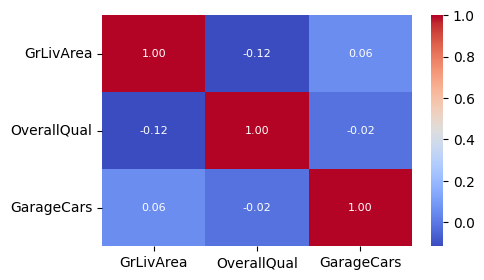

In [15]:
df_ = df[["GrLivArea", "OverallQual", "GarageCars"]]
# If two features are very correlated: corr > 0.85, keep only one.
plt.figure(figsize=(5,3))
sns.heatmap(
    df_.corr(),
    annot=True,           # show correlation values
    fmt=".2f",            # show 2 decimal places
    cmap="coolwarm",      # change color map
    annot_kws={"size":8}  # make numbers smaller
)
plt.show()

In [16]:
# it is usually better to normalize (scale) the features.
scaler = StandardScaler()
df_X_scaled = scaler.fit_transform(df_)
df_y = df[["SalePrice"]]
df_y_scaled = scaler.fit_transform(df_y)

### Normal Equation (Closed-Form Solution)
The Normal Equation is the analytical, closed-form solution to the Ordinary Least Squares (OLS) optimization problem. While OLS defines the goal of minimizing the sum of squared residuals, the Normal Equation provides the exact formula to calculate the parameter estimates directly.
$$
y = w_0 + w_1x_1 + w_2x_2 + w_3x_3 \\
Xw = y
$$
$$
\begin{bmatrix}
1 & x_{11} & x_{12} & x_{13} \\
1 & x_{21} & x_{22} & x_{23} \\
1 & x_{31} & x_{32} & x_{33} \\
. & . & . & . \\
. & . & . & .
\end{bmatrix}
\begin{bmatrix}
w_0 \\
w_1 \\
w_2 \\
w_3
\end{bmatrix}
=
\begin{bmatrix}
y_1 \\
y_2 \\
y_3 \\
. \\
.
\end{bmatrix}
$$
The regression solution is,
$$
w = (X^T X)^{-1} X^T y
$$

In [17]:
df_X = df_X_scaled
df_y = df_y_scaled
X = np.c_[np.ones(df_X.shape[0]), df_X]
y = df_y.flatten()
XT = X.T
w = np.linalg.inv(XT @ X) @ XT @ y

print("\nFinal Weights:")
print("w0 =", np.round(w[0], 2))
print("w1 =", np.round(w[1], 2))
print("w2 =", np.round(w[2], 2))
print("w3 =", np.round(w[3], 2))


Final Weights:
w0 = 0.0
w1 = 0.78
w2 = 0.45
w3 = 0.32


### Gradient Descent Algorithm

We are Starting from the OLS Loss function,  
to get mean squared error we put (1/n) to the formula. (1/2) gives a cleaner gradient output.
$$
L(w) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^T w)^2
$$

Derivative w.r.t \(w\):

$$
\frac{\partial}{\partial w} (y_i - x_i^T w)^2 = 2 (y_i - x_i^T w) \cdot \frac{\partial}{\partial w} (y_i - x_i^T w)
$$

$$
\frac{\partial}{\partial w} (y_i - x_i^T w) = -x_i
$$

$$
\frac{\partial}{\partial w} (y_i - x_i^T w)^2 = -2 (y_i - x_i^T w) x_i
$$
So, we get, 

$$
\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} - (y_i - x_i^T w) x_i
$$

$$
\frac{\partial L}{\partial w_0} = \frac{1}{n} \sum_{i=1}^{n} - (y_i - x_i^T w) \qquad \frac{\partial L}{\partial w_1} = \frac{1}{n} \sum_{i=1}^{n} - (y_i - x_i^T w) x_1 \qquad \frac{\partial L}{\partial w_2} = \frac{1}{n} \sum_{i=1}^{n} - (y_i - x_i^T w) x_2 \qquad \frac{\partial L}{\partial w_3} = \frac{1}{n} \sum_{i=1}^{n} - (y_i - x_i^T w) x_3
$$

Move w in the direction **opposite to the gradient** to reduce the loss.

$$
w \gets w - \alpha \frac{\partial L}{\partial w}
$$

### Sale Price Prediction Using OLS and Gradient Descent


Final Weights:
w0 = 0.0
w1 = 0.78
w2 = 0.45
w3 = 0.32


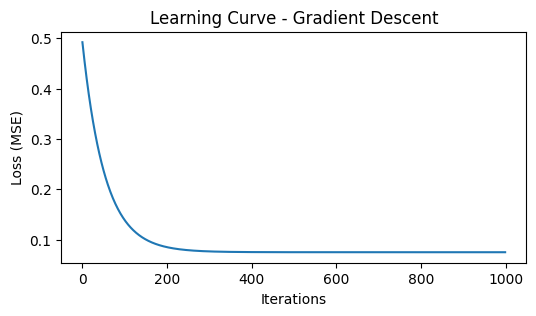

In [18]:
n = len(y)
w = np.zeros(4)
alpha = 0.01
iterations = 1000
loss_history = []

# Loss Function (Mean Squared Error)
def compute_loss(X, y, w):
    predictions = X @ w
    errors = y - predictions
    return (1/(2*n)) * np.sum(errors**2)

# Gradient Descent (Batch Gradient Descent)
for i in range(iterations):
    y_pred = X @ w
    error = y - y_pred
    gradient = -(1/n) * (X.T @ error)
    w = w - alpha * gradient

    loss = compute_loss(X, y, w)
    loss_history.append(loss)

print("\nFinal Weights:")
print("w0 =", np.round(w[0], 2))
print("w1 =", np.round(w[1], 2))
print("w2 =", np.round(w[2], 2))
print("w3 =", np.round(w[3], 2))

# Plot Learning Curve
plt.figure(figsize=(6, 3))
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Learning Curve - Gradient Descent")
plt.show()

### Target Values & Predictions

In [19]:
# comparing target/groundtruth values and predicted values of SalePrice
y = df["SalePrice"]
y_mean = np.mean(y)
y_std = np.std(y)
p = ((X @ w) * y_std) + y_mean
yp_df = pd.DataFrame({"Target Values":y, "Predicted Values":p})
yp_df

,Target Values,Predicted Values
0,177106,201648.654725
1,301044,280116.184362
2,360609,345708.063382
3,240556,261424.964688
4,193656,180376.962043
...,...,...
295,250604,261124.390683
296,329906,347388.720451
297,184623,214153.268531
298,303345,297294.012823


### Ridge Regression & Lasso Regression Loss Functions
Ridge Rigression,
$$
L(w) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - x_i^T w)^2 + \lambda \sum_{j=1}^{p} w_j^2
$$
Lasso Regression, 
$$
L(w) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - x_i^T w)^2 + \lambda \sum_{j=1}^{p} |w_j|
$$

These two loss functions contains regularization terms with L2 norm & L1 norm respectively